<a href="https://colab.research.google.com/github/buiswrld/eos-inference/blob/main/Neutron_Star_EOS_Phase_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Cell 1 - Project Setup
#Run at the start of every session for Google Drive
import os

from google.colab import drive
drive.mount('/content/drive')

#Project Root Set here
PROJECT_ROOT = '/content/drive/MyDrive/ns_eos_project'

Mounted at /content/drive


In [ ]:
# Cell 2 — folder structure

folders = [
    'data/raw',          # raw EOS samples and observation arrays
    'data/processed',    # cleaned/normalized versions for training
    'models',            # model architecture definitions (.py file/saved configs)
    'figures',           # all plots/visualizations
    'checkpoints',       # saved model weights (.pt files)
    'notebooks',         # experimental/scratch notebooks
]

for folder in folders:
    path = os.path.join(PROJECT_ROOT, folder)
    os.makedirs(path, exist_ok=True)
    print(f'✓ {path}')

print('\nProject structure created.')

✓ /content/drive/MyDrive/ns_eos_project/data/raw
✓ /content/drive/MyDrive/ns_eos_project/data/processed
✓ /content/drive/MyDrive/ns_eos_project/models
✓ /content/drive/MyDrive/ns_eos_project/figures
✓ /content/drive/MyDrive/ns_eos_project/checkpoints
✓ /content/drive/MyDrive/ns_eos_project/notebooks

Project structure created.


In [ ]:
# Cell 3 — verifies structure

for root, dirs, files in os.walk(PROJECT_ROOT):
    level = root.replace(PROJECT_ROOT, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')

ns_eos_project/
  models/
  notebooks/
  figures/
  data/
    raw/
    processed/
  checkpoints/


In [ ]:
# Cell 4 — path constants (import this at the top of every future notebook if we make more)

DATA_RAW       = os.path.join(PROJECT_ROOT, 'data/raw')
DATA_PROCESSED = os.path.join(PROJECT_ROOT, 'data/processed')
MODELS         = os.path.join(PROJECT_ROOT, 'models')
FIGURES        = os.path.join(PROJECT_ROOT, 'figures')
CHECKPOINTS    = os.path.join(PROJECT_ROOT, 'checkpoints')

print('Paths loaded:')
for name, path in [('DATA_RAW', DATA_RAW), ('DATA_PROCESSED', DATA_PROCESSED),
                   ('MODELS', MODELS), ('FIGURES', FIGURES), ('CHECKPOINTS', CHECKPOINTS)]:
    print(f'  {name}: {path}')

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def movetodevice(batch, device):
    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v):
            out[k] = v.to(device)
        else:
            out[k] = v
    return out

print(f"Device: {device}")

Paths loaded:
  DATA_RAW: /content/drive/MyDrive/ns_eos_project/data/raw
  DATA_PROCESSED: /content/drive/MyDrive/ns_eos_project/data/processed
  MODELS: /content/drive/MyDrive/ns_eos_project/models
  FIGURES: /content/drive/MyDrive/ns_eos_project/figures
  CHECKPOINTS: /content/drive/MyDrive/ns_eos_project/checkpoints
Device: cuda


In [ ]:
# Cell 5

import torch
import torch.nn as nn

class Model(nn.Module):
    def __init__(self, hidden_dim=64, input_dim=3, output_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

        # normalization constants per messenger type
        # (mean, std) for each feature — based on forward model ranges
        self.register_buffer('gw_mean',     torch.tensor([300.0, 1.2]))
        self.register_buffer('gw_std',      torch.tensor([80.0,  0.1]))
        self.register_buffer('nicer_mean',  torch.tensor([1.6,   11.5]))
        self.register_buffer('nicer_std',   torch.tensor([0.3,   1.0]))
        self.register_buffer('pulsar_mean', torch.tensor([2.0]))
        self.register_buffer('pulsar_std',  torch.tensor([0.2]))

    def normalize(self, x, mean, std):
        return (x - mean) / std.clamp(min=1e-6)

    def forward(self, batch):
        device = next(self.parameters()).device
        num_catalogs = batch["num_catalogs"]
        accumulator  = torch.zeros(num_catalogs, 3, device=device)
        counts       = torch.zeros(num_catalogs, 1, device=device)

        for obs_type, dim in [("gw", 2), ("nicer", 2), ("pulsar", 1)]:
            x   = batch[obs_type + "_x"]
            idx = batch[obs_type + "_catalog_idx"]

            if x.shape[0] == 0:
                continue

            # normalize
            if obs_type == "gw":
                x = self.normalize(x, self.gw_mean, self.gw_std)
            elif obs_type == "nicer":
                x = self.normalize(x, self.nicer_mean, self.nicer_std)
            elif obs_type == "pulsar":
                x = self.normalize(x, self.pulsar_mean, self.pulsar_std)

            # pad to input_dim=3
            if x.shape[1] < 3:
                pad = torch.zeros(x.shape[0], 3 - x.shape[1], device=device)
                x   = torch.cat([x, pad], dim=1)

            accumulator.scatter_add_(0, idx.unsqueeze(1).expand_as(x), x)
            counts.scatter_add_(0, idx.unsqueeze(1),
                                torch.ones(x.shape[0], 1, device=device))

        summary = accumulator / counts.clamp(min=1)
        return self.net(summary)

In [ ]:
# Dataset structure:
# ------------------
# This dataset is a list of catalog-level training examples.
#
# Each item corresponds to ONE synthetic neutron-star equation of state (EOS).
# The target is the EOS parameter vector used to generate that catalog:
#
#     theta_eos = [gamma0, gamma1, gamma2, gamma3]
#
# The input is a variable-size, unordered catalog of heterogeneous observations.
# Each observation is partial evidence about the same underlying EOS.
#
# Example item:
#
#     {
#         "theta_eos": [gamma0, gamma1, gamma2, gamma3],
#         "catalog": [
#             {
#                 "type": "gw",
#                 "x": [lambda_tilde, chirp_mass],
#                 "sigma": [sigma_lambda_tilde, sigma_chirp_mass]
#             },
#             {
#                 "type": "nicer",
#                 "x": [mass, radius],
#                 "sigma": [sigma_mass, sigma_radius]
#             },
#             {
#                 "type": "pulsar",
#                 "x": [mass],
#                 "sigma": [sigma_mass]
#             }
#         ]
#     }
#
# The target belongs to the WHOLE catalog, not to individual observations.
# The model learns q(theta_eos | catalog), where catalog is a heterogeneous set.
#
# During batching, observations are grouped by messenger type and assigned a
# catalog_index telling the model which catalog in the batch they belong to.
# This supports variable-size catalogs without padding the whole catalog.

# this is the convention I'll be using when I defien the dataset below, I had chatgpt generate the above description ig.

In [ ]:
# Cell 6
from torch.utils.data import Dataset

class CustomDataset(Dataset):
  def __init__(self, samples):
    self.samples = samples

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    sample = self.samples[idx]
    theta = torch.tensor(sample["theta_eos"], dtype = torch.float32)
    catalog = []

    for obs in sample["catalog"]:
      obs_type = obs["type"].lower()
      x = torch.tensor(obs["x"], dtype = torch.float32)
      sigma = torch.tensor(obs["sigma"], dtype = torch.float32)

      catalog.append({"type": obs_type, "x": x, "sigma": sigma})

    return {"theta": theta, "catalog": catalog}

def collate_fn(batch):
  lister = []
  for i in batch:
    lister.append(i["theta"])
  theta = torch.stack(lister, dim = 0)
  num_catalogs = len(batch)

  grouped = {
        "gw": {
            "x": [],
            "sigma": [],
            "catalog_idx": [],
            "dim": 2,
        },
        "nicer": {
            "x": [],
            "sigma": [],
            "catalog_idx": [],
            "dim": 2,
        },
        "pulsar": {
            "x": [],
            "sigma": [],
            "catalog_idx": [],
            "dim": 1,
        },
    }

  for catidx, item in enumerate(batch):
    for obs in item["catalog"]:
      obs_type = obs["type"]
      grouped[obs_type]["x"].append(obs["x"])
      grouped[obs_type]["sigma"].append(obs["sigma"])
      grouped[obs_type]["catalog_idx"].append(catidx)

  output = {"theta": theta, "num_catalogs": num_catalogs}

  for obs_type, vals in grouped.items():
    if len(vals["x"]) > 0:
      output[obs_type + "_x"] = torch.stack(vals["x"], dim = 0)
      output[obs_type + "_sigma"] = torch.stack(vals["sigma"], dim = 0)
      output[obs_type + "_catalog_idx"] = torch.tensor(vals["catalog_idx"], dtype=torch.long)

    else:
      output[obs_type + "_x"] = torch.empty(0, vals["dim"], dtype=torch.float32)
      output[obs_type +"_sigma"] = torch.empty(0, vals["dim"], dtype=torch.float32)
      output[obs_type + "_catalog_idx"] = torch.empty(0, dtype=torch.long)

  return output

In [ ]:
# Cell 7 - Forward model + toy dataset generation

import torch
import random

def forward_model(theta_eos):
    """
    Toy forward model: EOS params -> synthetic multi-messenger observations.
    theta_eos: [gamma0, gamma1, gamma2, gamma3]

    Each observation independently samples a realistic measurement uncertainty
    (sigma) and then draws its measured value from N(true_value, sigma).
    This means sigma is honest: it reflects how noisy each measurement actually is,
    and the model can use it as an input to weight observations accordingly.

    Sigma ranges are loosely motivated by current detector capabilities:
      GW   - lambda_tilde: ~30-150 (LIGO O3-era posterior widths)
           - chirp_mass:   ~0.001-0.008 M_sun (very precisely measured)
      NICER - mass:   ~0.04-0.15 M_sun
            - radius: ~0.3-1.0 km
      Pulsar mass: ~0.005-0.025 M_sun
    """
    g0, g1, g2, g3 = theta_eos

    # Noiseless observable values from EOS params (linear toy model)
    lambda_tilde_true = 200 + 80*g0 + 70*g1 + 30*g2 + 500*g3
    chirp_mass_true   = 1.2 + 0.15*g0 - 0.12*g1 + 0.08*g2 - 2.0*g3
    mass_true         = 1.4 + 0.15*g0 + 0.18*g1 - 0.10*g2 + 3.0*g3
    radius_true       = 11.0 + 0.8*g0 - 0.7*g1 + 0.9*g2 + 10.0*g3
    pulsar_mass_true  = 1.8 + 0.15*g0 + 0.12*g1 + 0.10*g2 - 4.0*g3

    observations = []

    # GW events: present in ~80% of catalogs, 1-3 events each
    if random.random() < 0.8:
        for _ in range(random.randint(1, 3)):
            sigma_lambda = random.uniform(30.0, 150.0)
            sigma_mc     = random.uniform(0.001, 0.008)
            observations.append({
                "type":  "gw",
                "x":     [lambda_tilde_true + random.gauss(0, sigma_lambda),
                          chirp_mass_true   + random.gauss(0, sigma_mc)],
                "sigma": [sigma_lambda, sigma_mc]
            })

    # NICER X-ray: present in ~70% of catalogs, 1-2 sources each
    if random.random() < 0.7:
        for _ in range(random.randint(1, 2)):
            sigma_mass   = random.uniform(0.04, 0.15)
            sigma_radius = random.uniform(0.3, 1.0)
            observations.append({
                "type":  "nicer",
                "x":     [mass_true   + random.gauss(0, sigma_mass),
                          radius_true + random.gauss(0, sigma_radius)],
                "sigma": [sigma_mass, sigma_radius]
            })

    # Pulsar timing mass: present in ~60% of catalogs, one measurement
    if random.random() < 0.6:
        sigma_pm = random.uniform(0.005, 0.025)
        observations.append({
            "type":  "pulsar",
            "x":     [pulsar_mass_true + random.gauss(0, sigma_pm)],
            "sigma": [sigma_pm]
        })

    # Guarantee at least one observation per catalog
    if len(observations) == 0:
        sigma_lambda = random.uniform(30.0, 150.0)
        sigma_mc     = random.uniform(0.001, 0.008)
        observations.append({
            "type":  "gw",
            "x":     [lambda_tilde_true + random.gauss(0, sigma_lambda),
                      chirp_mass_true   + random.gauss(0, sigma_mc)],
            "sigma": [sigma_lambda, sigma_mc]
        })

    return observations


def generate_toy_sample():
    theta_eos = [
        random.uniform(0.2,   2.0),
        random.uniform(-1.6,  1.7),
        random.uniform(-0.6,  0.6),
        random.uniform(-0.02, 0.02),
    ]
    catalog = forward_model(theta_eos)
    return {"theta_eos": theta_eos, "catalog": catalog}


toy_samples = [generate_toy_sample() for _ in range(500)]
dataset     = CustomDataset(toy_samples)

print(f"Generated {len(dataset)} samples")
print("\nFirst sample — EOS params:", [f"{v:.4f}" for v in toy_samples[0]["theta_eos"]])
print("Catalog:")
for obs in toy_samples[0]["catalog"]:
    print(f"  {obs['type']:>6}  x={[f'{v:.3f}' for v in obs['x']]}  sigma={[f'{v:.4f}' for v in obs['sigma']]}")

In [ ]:
# Cell 7b — Data inspection: sigma distributions and normalization stats
#
# Run this after generating toy_samples.
# Outputs normalization stats for x and sigma that Part 2 (the encoders) will need.

import numpy as np
import matplotlib.pyplot as plt

# Collect all observations across the full dataset
gw_data, nicer_data, pulsar_data = [], [], []

for sample in toy_samples:
    for obs in sample["catalog"]:
        row = obs["x"] + obs["sigma"]
        if obs["type"] == "gw":
            gw_data.append(row)
        elif obs["type"] == "nicer":
            nicer_data.append(row)
        elif obs["type"] == "pulsar":
            pulsar_data.append(row)

gw_arr     = np.array(gw_data)     # shape (N, 4): lambda, mc, sigma_lambda, sigma_mc
nicer_arr  = np.array(nicer_data)  # shape (N, 4): mass, radius, sigma_mass, sigma_radius
pulsar_arr = np.array(pulsar_data) # shape (N, 2): mass, sigma_mass

print(f"Observation counts: {len(gw_arr)} GW | {len(nicer_arr)} NICER | {len(pulsar_arr)} Pulsar")

# Print normalization stats (mean and std) for encoder inputs
# The person building the encoders (Part 2) should use these to normalize inputs.
encoder_specs = [
    ("GW encoder     [lambda_tilde, chirp_mass, sigma_lambda, sigma_mc]",
     gw_arr,     ["lambda_tilde", "chirp_mass", "sigma_lambda", "sigma_mc"]),
    ("NICER encoder  [mass, radius, sigma_mass, sigma_radius]",
     nicer_arr,  ["mass", "radius", "sigma_mass", "sigma_radius"]),
    ("Pulsar encoder [mass, sigma_mass]",
     pulsar_arr, ["mass", "sigma_mass"]),
]

print("\n--- Encoder input normalization stats ---")
for title, arr, labels in encoder_specs:
    print(f"\n{title}")
    for i, label in enumerate(labels):
        print(f"  {label:>15}:  mean={arr[:, i].mean():8.4f}  std={arr[:, i].std():8.4f}")

# Plot 1: sigma distributions per messenger type
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Measurement uncertainty (sigma) distributions across toy dataset", fontsize=13)

axes[0].hist(gw_arr[:, 2], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title("GW: $\\sigma(\\tilde{\\Lambda})$")
axes[0].set_xlabel("$\\sigma_{\\lambda}$")
axes[0].set_ylabel("Count")

axes[1].hist(nicer_arr[:, 2], bins=30, color='darkorange', alpha=0.8, edgecolor='white')
axes[1].set_title("NICER: $\\sigma(M)$")
axes[1].set_xlabel("$\\sigma_{mass}$ [$M_\\odot$]")

axes[2].hist(pulsar_arr[:, 1], bins=30, color='seagreen', alpha=0.8, edgecolor='white')
axes[2].set_title("Pulsar: $\\sigma(M)$")
axes[2].set_xlabel("$\\sigma_{mass}$ [$M_\\odot$]")

plt.tight_layout()
plt.savefig(f'{FIGURES}/sigma_distributions.png', dpi=150)
plt.show()

# Plot 2: observed x values per messenger type
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Observed values across toy dataset", fontsize=13)

axes[0].scatter(gw_arr[:, 0], gw_arr[:, 1], alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel("$\\tilde{\\Lambda}$")
axes[0].set_ylabel("Chirp mass [$M_\\odot$]")
axes[0].set_title("GW observations")

axes[1].scatter(nicer_arr[:, 0], nicer_arr[:, 1], alpha=0.3, s=10, color='darkorange')
axes[1].set_xlabel("Mass [$M_\\odot$]")
axes[1].set_ylabel("Radius [km]")
axes[1].set_title("NICER observations")

axes[2].hist(pulsar_arr[:, 0], bins=30, color='seagreen', alpha=0.8, edgecolor='white')
axes[2].set_xlabel("Mass [$M_\\odot$]")
axes[2].set_ylabel("Count")
axes[2].set_title("Pulsar mass measurements")

plt.tight_layout()
plt.savefig(f'{FIGURES}/observation_distributions.png', dpi=150)
plt.show()

print(f"\nPlots saved to {FIGURES}/")

In [ ]:
# target normalization constants
theta_mean = torch.tensor([1.1,  0.05, 0.0,  0.0],   device=device)
theta_std  = torch.tensor([0.52, 0.96, 0.35, 0.012], device=device)

def normalize_theta(theta):
    return (theta - theta_mean) / theta_std

def denormalize_theta(theta_norm):
    return theta_norm * theta_std + theta_mean

In [ ]:
# Training loop

from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataloader = DataLoader(
    dataset, batch_size=32, shuffle=True, collate_fn=collate_fn
)

model     = Model(hidden_dim=64).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
criterion = nn.MSELoss()
num_epochs = 200

for epoch in range(num_epochs):
    model.train()
    total_loss, steps = 0.0, 0

    for batch in dataloader:
        batch  = movetodevice(batch, device)
        theta      = batch["theta"]
        theta_norm = normalize_theta(theta)
        pred_norm  = model(batch)
        loss       = criterion(pred_norm, theta_norm)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        steps      += 1

    mean_loss = total_loss / steps
    if epoch % 20 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:3d} | loss = {mean_loss:.6f}")

torch.save({
    'epoch':                num_epochs,
    'model_state_dict':     model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'final_loss':           mean_loss,
}, f'{CHECKPOINTS}/toy_model.pt')

print(f"\nCheckpoint saved to {CHECKPOINTS}/toy_model.pt")

Epoch   0 | loss = 0.895948
Epoch  20 | loss = 0.590647
Epoch  40 | loss = 0.583273
Epoch  60 | loss = 0.582588
Epoch  80 | loss = 0.573795
Epoch 100 | loss = 0.573161
Epoch 120 | loss = 0.575538
Epoch 140 | loss = 0.568983
Epoch 160 | loss = 0.572558
Epoch 180 | loss = 0.569983
Epoch 199 | loss = 0.566232

Checkpoint saved to /content/drive/MyDrive/ns_eos_project/checkpoints/toy_model.pt


True EOS vs Predicted EOS (first 5):
        g0_true    g0_pred |    g1_true    g1_pred
-------------------------------------------------------
   0     0.2250     0.5276 |     1.5294     1.0300
   1     1.5625     1.0160 |     1.1239     1.0961
   2     1.4017     0.8255 |    -1.0031    -0.5738
   3     0.2757     0.9768 |    -0.5495    -0.8417
   4     1.0636     0.8402 |     0.1630     0.2369


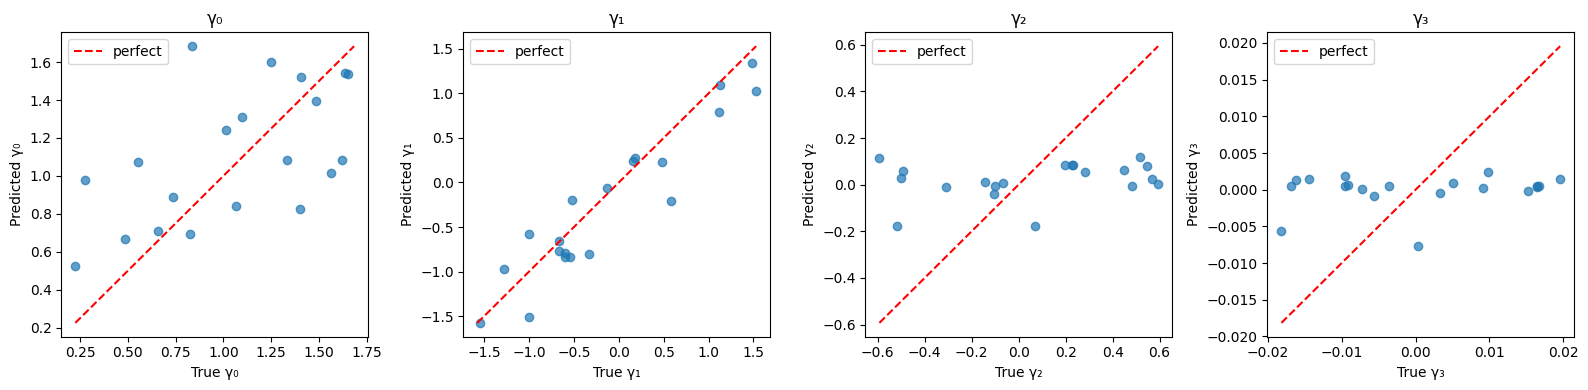

Plot saved to /content/drive/MyDrive/ns_eos_project/figures/true_vs_predicted.png


In [ ]:
# Test cell

model.eval()

# generate fresh test samples
test_samples = [generate_toy_sample() for _ in range(20)]
test_dataset  = CustomDataset(test_samples)
test_loader   = DataLoader(test_dataset, batch_size=20,
                           shuffle=False, collate_fn=collate_fn)

with torch.no_grad():
    for batch in test_loader:
        batch  = movetodevice(batch, device)
        theta  = batch["theta"].cpu()
        pred   = model(batch).cpu()

pred = denormalize_theta(model(batch)).cpu()

print("True EOS vs Predicted EOS (first 5):")
print(f"{'':>4} {'g0_true':>10} {'g0_pred':>10} | "
      f"{'g1_true':>10} {'g1_pred':>10}")
print("-" * 55)
for i in range(5):
    print(f"{i:>4} {theta[i,0]:>10.4f} {pred[i,0]:>10.4f} | "
          f"{theta[i,1]:>10.4f} {pred[i,1]:>10.4f}")

# plot true vs predicted
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
param_names = ['γ₀', 'γ₁', 'γ₂', 'γ₃']

for i, ax in enumerate(axes):
    ax.scatter(theta[:, i].detach().numpy(), pred[:, i].detach().numpy(), alpha=0.7)
    mn = min(theta[:, i].min(), pred[:, i].min()).item()
    mx = max(theta[:, i].max(), pred[:, i].max()).item()
    ax.plot([mn, mx], [mn, mx], 'r--', label='perfect')
    ax.set_xlabel(f'True {param_names[i]}')
    ax.set_ylabel(f'Predicted {param_names[i]}')
    ax.set_title(param_names[i])
    ax.legend()

plt.tight_layout()
plt.savefig(f'{FIGURES}/true_vs_predicted.png')
plt.show()
print(f"Plot saved to {FIGURES}/true_vs_predicted.png")